# Scores plot

The scores plot draws each observation as a point in the space of two components, with the origin marked by crosshairs and, optionally, one color per class.

It is model-agnostic: it takes a **scores matrix** (observations in rows, components in columns), so anything that produces scores such as, PCA, PLS, CCA, JIVE, etc can be drawn with it.

    plot_scores(scores; group = ..., comps = (1, 2), kwargs...)

This notebook simulates a small data set, fits a PCA, shows the default plot, and then works through every way to modify it.

## Setup

`BigRiverEssence` supplies the models, `WolfRiverPlots` the plotting verbs, and `Plots` the engine the recipes extend. 

In [21]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs



## A simulated example

Three latent signals drive twenty variables, plus a little noise. The class label is read off the first latent signal, so the observations fall into three groups that PCA should separate along the first component.

This is the same simulation used in the other notebooks, so the figures are comparable across plots.

In [22]:
rng = StableRNG(20240801)

n = 90    # observations
p = 20    # variables

# three latent signals drive the variables
latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

# the class is read off the first latent signal
y = [latent[i, 1] > 0.4 ? "a" : latent[i, 1] < -0.4 ? "c" : "b" for i in 1:n]

size(X), unique(y)

((90, 20), ["b", "a", "c"])

## Fitting the model

Now we use `pca` from `BigRiverEssence` to fit a Principal Component Analysis.

In [23]:
m = pca(X; k = 5)
S = pca_transform(m, X)

size(S)   # observations by components

(90, 5)

## The default plot

With nothing but the scores, the recipe draws the first two components, marks the origin, and labels the axes generically. No grouping was given, so every observation goes into one series and no legend is drawn.

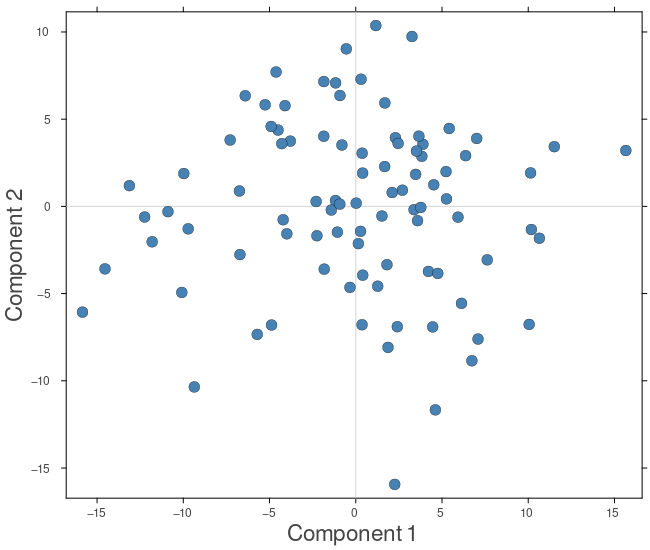

In [5]:
plot_scores(S)

---

# Modifying the plot

The knobs come in three tiers, and it is worth keeping them apart:

1. **Data-selecting arguments** — `group`, `comps`. These change *what is drawn*.
2. **Recipe keywords** — `origincolor`. Styling knobs the recipe defines itself.
3. **Standard `Plots` attributes** — `title`, `marker`, `legend`, `size`, and every other `Plots` attribute. 


## 1. Data-selecting arguments

### `group` — one color per class

Passing a grouping vector splits the observations into one series per level. That gives categorical colors and one legend entry per class, rather than the continuous colorbar a `marker_z` would produce. The legend appears automatically once there is more than one level.

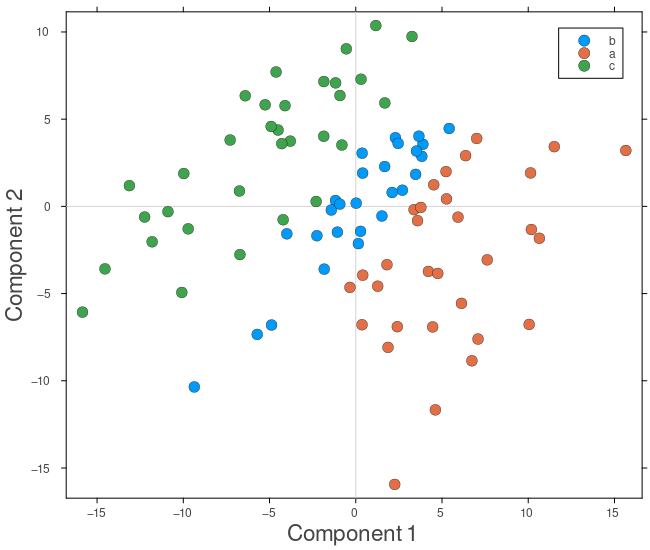

In [6]:
plot_scores(S; group = y)

The legend text comes straight from the group vector, so relabelling the vector relabels the legend.

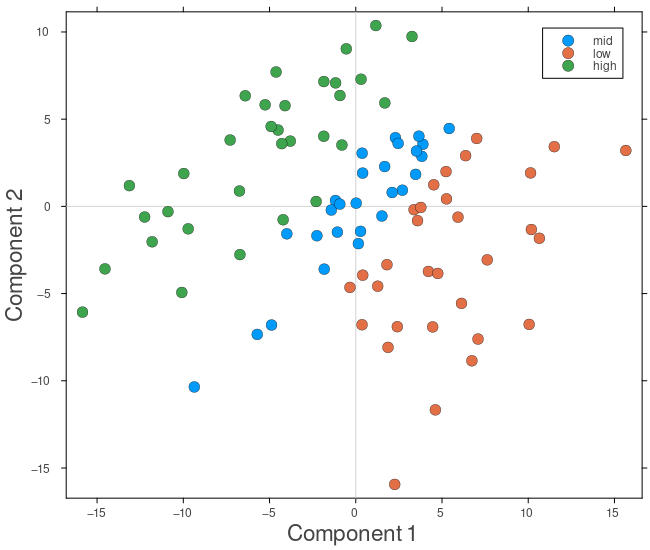

In [7]:
plot_scores(S; group = replace(y, "a" => "low", "b" => "mid", "c" => "high"))

### `comps` — which pair of components

By default the first two components are drawn. `comps` picks any other pair. Note the axis labels do **not** follow automatically — they are generic defaults, so set them yourself when you move off the first two.

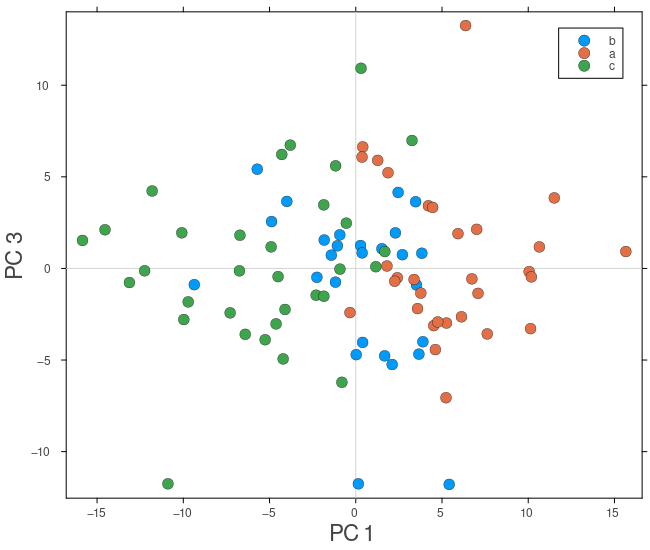

In [8]:
plot_scores(S; group = y, comps = (1, 3),
            xlabel = "PC 1", ylabel = "PC 3")

## 2. Recipe keywords

### `origincolor` — the crosshairs at zero

The recipe draws a vertical and a horizontal line through the origin. `origincolor` sets their color; it defaults to a light grey that reads as a background reference rather than as data.

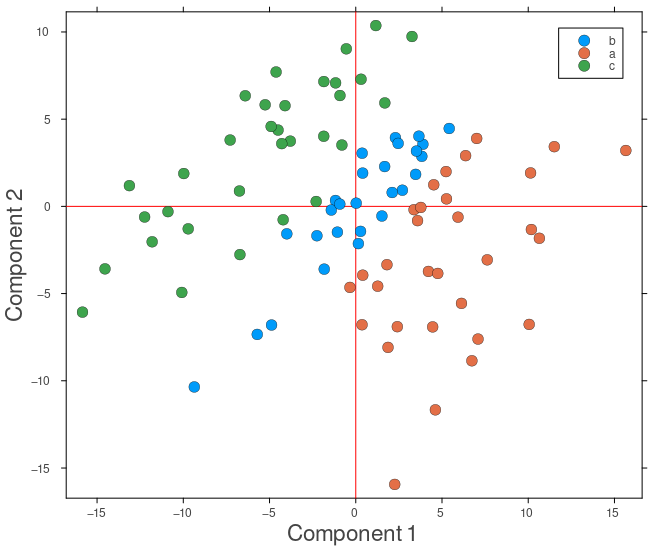

In [24]:
plot_scores(S; group = y, origincolor = :red)

## 3. Standard `Plots` attributes

We can maually set the plot attributes such as explicitly set plot title, marker, legend position and size of the plot.

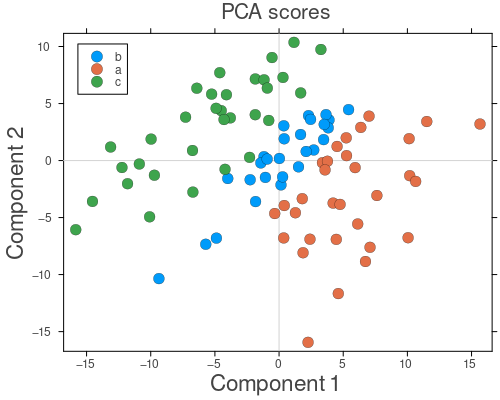

In [25]:
plot_scores(S; group = y,
            title  = "PCA scores",
            marker = 12,
            legend = :topleft,
            size   = (500, 400))

Turning the legend off entirely:

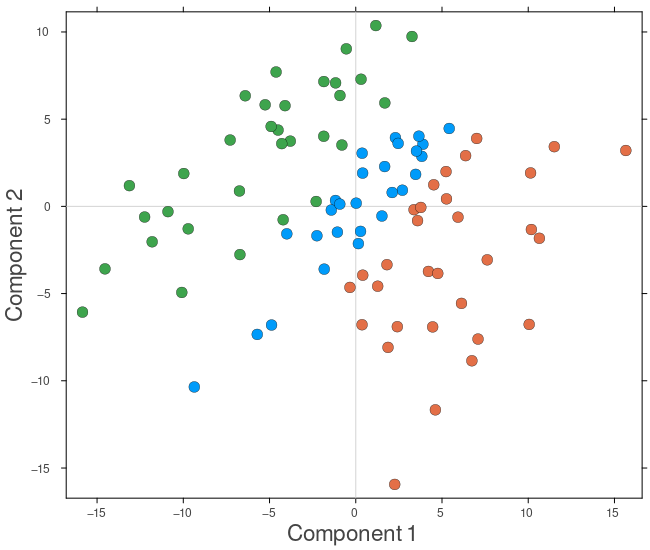

In [26]:
plot_scores(S; group = y, legend = false)